In [1]:
# ==============================================================================
# LIGHTGBM (LIGHT GRADIENT BOOSTING MACHINE) HAKKINDA BİLGİ VE NOTLAR
# ==============================================================================

# 1. LIGHTGBM NEDİR?
# ------------------
# - Microsoft tarafından geliştirilen, karar ağaçlarına (Decision Trees) dayalı
#   yüksek performanslı bir Gradient Boosting framework'üdür.
# - XGBoost ve CatBoost gibi kütüphanelere güçlü bir alternatiftir.

# 2. NE İŞE YARAR & NEREDE KULLANILIR?
# -----------------------------------
# - Sınıflandırma (Classification): Müşteri kayıp tahmini (Churn), spam tespiti, vb.
# - Regresyon (Regression): Ev/araba fiyat tahmini, satış miktarı öngörüsü, vb.
# - Sıralama (Ranking): Arama motoru sonuçları ve öneri sistemleri sıralaması.
# - Özellikle Excel/CSV türündeki TABLOSAL (Tabular) verilerde en iyi sonucu verir.

# 3. AVANTAJLARI (NEDEN TERCİH EDİLİR?)
# ------------------------------------
# - Hız ve Düşük Bellek: Büyük veri setlerinde çok hızlı eğitilir, RAM'i az harcar.
# - Yaprak Odaklı Büyüme (Leaf-wise): Ağacı seviye seviye değil, en çok kayıp
#   düşüren yapraktan büyütür; bu da modeli daha isabetli (accurate) yapar.
# - Kategorik Değişken Desteği: Kategorik verileri dahili olarak işleyebilir.

# 4. TEMEL KULLANIM ADIMLARI (ÇALIŞMA MANTIĞI)
# --------------------------------------------
# Step 1: Kütüphaneyi içe aktar -> import lightgbm as lgb
# Step 2: Modeli tanımla      -> model = lgb.LGBMClassifier() veya LGBMRegressor()
# Step 3: Modeli eğit        -> model.fit(X_train, y_train)
# Step 4: Tahmin yap         -> predictions = model.predict(X_test)
# ==============================================================================

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [5]:
df = sns.load_dataset('titanic')

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# EDA 

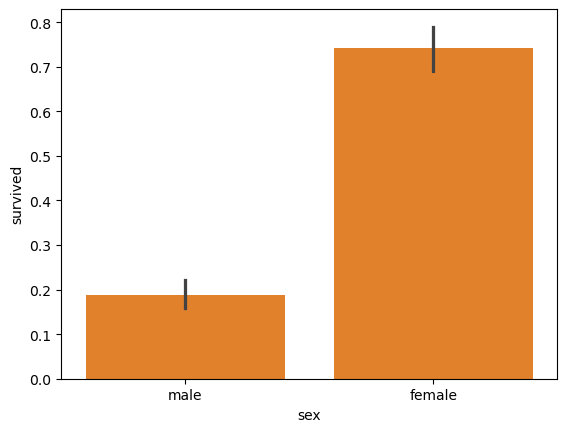

In [10]:
sns.barplot(data=df,x='sex',y='survived')
plt.show()

In [11]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [12]:
# gemi batarken kadinlara oncelik verildigini anliyoruz 

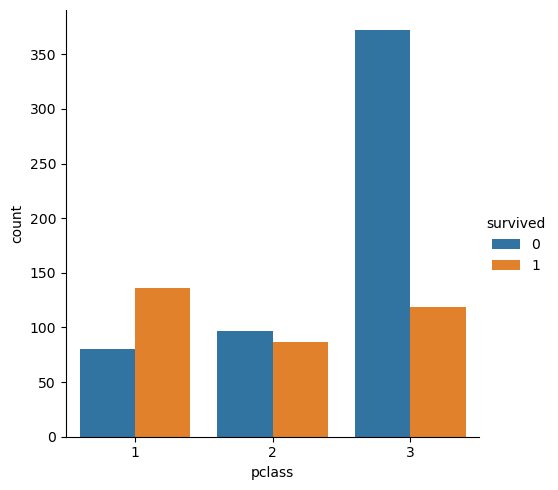

In [13]:
sns.catplot(data=df,x='pclass',hue='survived',kind='count')
plt.show()

In [17]:
# 3. sinif yolcularda olum oranin daha fazla oldugu anlasiliyor 

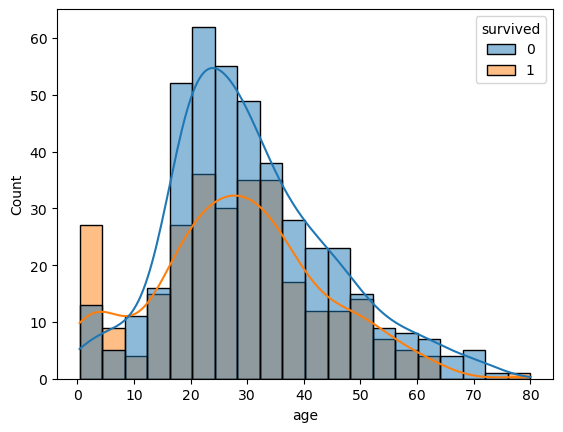

In [15]:
sns.histplot(data=df,x='age',hue='survived',kde=True)
plt.show()

In [16]:
# kurtarilmada cocuklara ve yaslilara daha fazlkla oncelik verildigini anliyoruz burada 

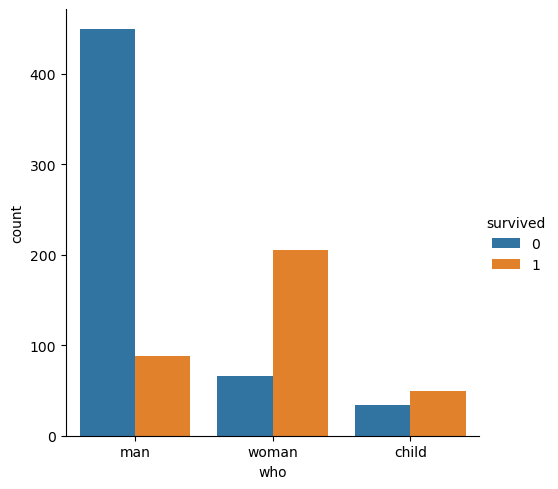

In [19]:
sns.catplot(data=df,x='who',hue='survived',kind='count')
plt.show()

In [20]:
# erkelerin cogu kurtulamamis 

In [21]:
## FEATURE ENGINERING 

In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [23]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [26]:
df.shape

(891, 15)

In [28]:
# deck verisinde cok kayip var ve isimede yaramiyor bundan dolayi silmeyi tercih edicem 
# alive kolonu suan isime yariamiyor bundan doalyi onuda silicem 
# embark town kismini silicem cunku embarked zaten bunun aynisi 

In [29]:
df = df.drop(['deck','embark_town','alive'],axis=1)

In [32]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [33]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
# age kisminin iseme yarayacagini dusunuyorum bundan dolayi bosluklari dolduracam  median ve mean arasinda cok fark yok birisini secip dolduracam 

In [35]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [36]:
df['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [37]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [38]:
# ==============================================================================
# 📌 LightGBM'in Hata ve Eksik Veri Toleransı (Error Tolerance & Missing Values)
# ==============================================================================

# 1. GOSS (Gradient-based One-Side Sampling) & Hata Odaklılık:
#    - LightGBM, her adımda önceki ağacın yaptığı hatalara (artıklara / residuals) odaklanır.
#    - Yüksek hataya (büyük gradyana) sahip zor örneklerin tamamını tutarken,
#      hatası düşük örneklerden rastgele seçim yapar.
#    - Böylece model, zor ve hatalı verileri hızlıca düzeltmeye odaklanır.

# 2. Eksik Veri (Missing Value / NaN) Toleransı:
#    - Ön işleme (Imputation / doldurma) yapmaya gerek kalmadan NaN değerleri kabul eder.
#    - Ağaç dallanmaları (split) sırasında eksik değerleri kayıpları en çok
#      azaltan yöne otomatik olarak yönlendirir.

# 3. Gürültülü Veriye ve Overfitting'e Karşı Önlemler (Regularization):
#    - reg_alpha (L1) & reg_lambda (L2): Aşırı öğrenmeyi engelleyerek gürültülü verilerin
#      modeli bozmasını önler.
#    - min_child_samples: Tekil hatalı verilerin bağımsız yaprak (leaf) oluşturmasını engeller.
#    - early_stopping_rounds: Doğrulama hatası (validation error) artmaya başladığında
#      eğitimi otomatik durdurur.
# ==============================================================================

In [39]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [40]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [41]:
df['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [42]:
df['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [43]:
# buradaki verilermizde icindekilerde bir baglanti olmadigi icin one hot encoding yapmayi daha cok uygun goruyorum 

In [45]:
df['adult_male']

0       True
1      False
2      False
3      False
4       True
       ...  
886     True
887    False
888    False
889     True
890     True
Name: adult_male, Length: 891, dtype: bool

In [46]:
df['alone']

0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: alone, Length: 891, dtype: bool

In [47]:
# df infonda zaten bool  oldugu gozukuyordu ben bnunlari 0 ve 1 e donusturecem 

In [48]:
df['adult_male'] = df['adult_male'].astype(int)

In [49]:
df['alone'] = df['alone'].astype(int)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    int64   
 11  alone       891 non-null    int64   
dtypes: category(1), float64(2), int64(6), object(3)
memory usage: 77.7+ KB


In [52]:
df['alone']

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: alone, Length: 891, dtype: int64

In [53]:
df['adult_male']

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: adult_male, Length: 891, dtype: int64

In [54]:
X = df.drop('survived',axis=1)
y = df['survived']

In [56]:
from sklearn.model_selection import train_test_split

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [60]:
categorical_cols = ["sex", "class", "embarked", "who"]

preprocessor = ColumnTransformer(transformers=
    [
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [61]:
# ==============================================================================
# 📌 ColumnTransformer & OneHotEncoder Notları
# ==============================================================================
# 1. categorical_cols: Dönüştürülecek kategorik sütunların listesi.
# 2. ColumnTransformer: Farklı sütunlara farklı işleme adımları uygulamayı sağlar.
# 3. OneHotEncoder:
#    - drop="first": Multicollinearity (dummy variable trap) engeller.
#    - handle_unknown="ignore": Test verisindeki bilinmeyen kategorilerde hata vermez.
# 4. remainder="passthrough": Belirtilmeyen sayısal sütunlara dokunmaz, aynen tutar.
# 5. fit_transform(X_train): Eğitir ve dönüştürür (sadece Train setine).
# 6. transform(X_test): Sadece dönüştürür (Data Leakage engellemek için Test setine).
# ==============================================================================

In [62]:
encoded_cols = preprocessor.get_feature_names_out()

In [63]:
X_train = pd.DataFrame(X_train,columns=encoded_cols)
X_test = pd.DataFrame(X_test,columns=encoded_cols)

In [65]:
# ==============================================================================
# 📌 NumPy Matrisini Tekrar DataFrame'e Dönüştürme
# ==============================================================================
# 1. get_feature_names_out(): ColumnTransformer sonrası oluşan yeni ve değişmeyen 
#    tüm sütun isimlerini çeker.
# 2. pd.DataFrame(..., columns=...): fit_transform sonrası NumPy dizisine 
#    dönüşen X_train ve X_test'i tekrar sütun isimleriyle birlikte DataFrame yapar.
# ==============================================================================

In [64]:
X_train

,cat__sex_male,cat__class_Second,cat__class_Third,cat__embarked_Q,cat__embarked_S,cat__who_man,cat__who_woman,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,27.0,0.0,0.0,7.8958,1.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,17.0,0.0,0.0,10.5000,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,28.0,0.0,0.0,0.0000,1.0,1.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,26.0,0.0,0.0,8.0500,1.0,1.0
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,43.0,0.0,0.0,8.0500,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,28.0,0.0,0.0,7.8958,1.0,1.0
664,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,19.0,0.0,0.0,30.0000,0.0,1.0
665,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,48.0,1.0,0.0,76.7292,1.0,0.0
666,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,18.0,0.0,0.0,11.5000,1.0,1.0


In [66]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 7.8 MB/s eta 0:00:00


In [67]:
import lightgbm as lgb 

In [68]:
from sklearn.metrics import classification_report,confusion_matrix

In [70]:
clf = lgb.LGBMClassifier(verbosity=-1,n_job=-1)
clf.fit(X_train,y_train)

LGBMClassifier(n_job=-1, verbosity=-1)

In [71]:
y_pred = clf.predict(X_test)

In [72]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test ))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       128
           1       0.75      0.76      0.75        95

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.79      0.79      0.79       223

[[104  24]
 [ 23  72]]


In [73]:
clf.feature_importances_

array([  60,   41,   51,   35,   81,   19,   36,   10,  865,   65,   77,
       1132,    0,   41], dtype=int32)

In [74]:
X_train.columns

Index(['cat__sex_male', 'cat__class_Second', 'cat__class_Third',
       'cat__embarked_Q', 'cat__embarked_S', 'cat__who_man', 'cat__who_woman',
       'remainder__pclass', 'remainder__age', 'remainder__sibsp',
       'remainder__parch', 'remainder__fare', 'remainder__adult_male',
       'remainder__alone'],
      dtype='object')

In [75]:
# daha guzel bir feature importance tablosu olsutura biliriz daha iyi gormemizmizi saglar bizim icin

In [80]:
importances = clf.feature_importances_
feature_names = X_train.columns
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances
    }
).sort_values(by='Importance')

In [81]:
feature_importance

,Feature,Importance
12,remainder__adult_male,0
7,remainder__pclass,10
5,cat__who_man,19
3,cat__embarked_Q,35
6,cat__who_woman,36
1,cat__class_Second,41
13,remainder__alone,41
2,cat__class_Third,51
0,cat__sex_male,60
9,remainder__sibsp,65


In [84]:
# HYPERPARAMETER TUNING 

In [85]:
from sklearn.model_selection import RandomizedSearchCV

In [86]:
lgb_model = lgb.LGBMClassifier(verbosity=-1)

In [87]:
param_grid = {
    'n_estimators':[100,200,300,500],
    'max_depth':[3,5,7,-1],
    'learning_rate':[0.01,0.05,0.1,0.3],
    'num_leaves':[15,31,63,127],
    'min_child_samples':[10,20,30],
    'subsample':[0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0]
}

In [88]:
random_search = RandomizedSearchCV(estimator=lgb_model,param_distributions=param_grid,cv=5,scoring='accuracy',verbose=1,n_jobs=-1)

In [89]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, -1],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 200, 300, 500],
                                        'num_leaves': [15, 31, 63, 127],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='accuracy', verbose=1)

In [90]:
random_search.best_params_

{'subsample': 0.6,
 'num_leaves': 31,
 'n_estimators': 500,
 'min_child_samples': 10,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [91]:
y_pred = random_search.predict(X_test)

In [92]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       133
           1       0.78      0.83      0.81        90

    accuracy                           0.84       223
   macro avg       0.83      0.84      0.83       223
weighted avg       0.84      0.84      0.84       223

[[112  21]
 [ 15  75]]


In [93]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

In [94]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       136
           1       0.72      0.79      0.75        87

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.79       223
weighted avg       0.80      0.80      0.80       223

[[109  27]
 [ 18  69]]


In [96]:
params = {
    'n_estimators':[100,200,300,500],
    'max_depth':[3,5,7,-1],
    'learning_rate':[0.01,0.05,0.1,0.3],
    'colsample_bytree':[0.6,0.8,1.0]
}

In [97]:
random_search = RandomizedSearchCV(estimator=XGBClassifier(),param_distributions=params,cv=5,scoring='accuracy',n_jobs=-1)

In [98]:
random_search.fit(X_train,y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\xgboost\core.py", line 553, in inner_f
    return func(**kwargs)
  File "C:\Users\PC\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1807, in fit
    self._Booster = train(
                    ~~~~~^
        para

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, -1],
                                        'n_estimators': [100, 200, 300, 500]},
                   scoring='accuracy')

In [100]:
y_pred = random_search.predict(X_test)

In [101]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       136
           1       0.76      0.84      0.80        87

    accuracy                           0.83       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.83      0.84       223

[[113  23]
 [ 14  73]]
